In [1]:
from PIL import Image
from transformers import  ViTFeatureExtractor, ViTModel
from sklearn.utils import resample

# ===============================
# Core Python Libraries
# ===============================
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from collections import Counter
from scipy.special import expit  # sigmoid

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ===============================
# NLP: NLTK & Gensim
# ===============================
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams

# ===============================
# Scikit-learn: Preprocessing, Models, Metrics
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


# ===============================
# Transformers (Hugging Face)
# ===============================
from transformers import (
    AutoTokenizer, AutoModel,
    RobertaTokenizer, RobertaModel,
    BertTokenizer, BertForSequenceClassification,
    XLNetTokenizer, XLNetForSequenceClassification
)
from torch.optim import AdamW
import torch
# ===============================
# Custom Modules
# ===============================
from metrics_calculator import MetricsCalculator
from graphs import GraphPlotter
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)


In [2]:
import nltk

# Tokenizer
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Stopwords
nltk.download('stopwords', quiet=True)

# WordNet for lemmatizer
nltk.download('wordnet', quiet=True)

#  POS tagging for better lemmatization
nltk.download('averaged_perceptron_tagger', quiet=True)


True

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# ViT for images
vit_model_name = "google/vit-base-patch16-224"
vit_model = ViTModel.from_pretrained(vit_model_name).to(device)
vit_model.eval()
vit_feature_extractor = ViTFeatureExtractor.from_pretrained(vit_model_name)

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\models\vit\feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [4]:
# -------------------------
# Preprocessing helpers
# -------------------------
def preprocess_image(file_path):
    print(file_path)
    img = Image.open(file_path).convert("RGB")
    inputs = vit_feature_extractor(images=img, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)
    return pixel_values  # shape: [1, 3, 224, 224]

# -------------------------
# ViT Feature extraction
# -------------------------
def extract_features_image(pixel_values):
    with torch.no_grad():
        outputs = vit_model(pixel_values)
    pooled = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return pooled

# -------------------------
# Dataset loader
# -------------------------
def load_dataset_vit(model_folder, dataset_path):
    os.makedirs(model_folder, exist_ok=True)

    x_image_path = os.path.join(model_folder, "X_Image_ViT.npy")
    y_image_path = os.path.join(model_folder, "Y_Image_ViT.npy")

    # Load cached datasets
    if all(os.path.exists(p) for p in [x_image_path, y_image_path]):
        print("🔹 Loading cached datasets...")
        X_image = np.load(x_image_path, allow_pickle=True)
        Y_image = np.load(y_image_path, allow_pickle=True)

        # -----------------------------
        # Resample Image Dataset to 1300 per class
        # -----------------------------
        X_image_resampled = []
        Y_image_resampled = []
        
        for cls in np.unique(Y_image):
            X_cls = X_image[Y_image == cls]
            Y_cls = Y_image[Y_image == cls]
        
            X_res, Y_res = resample(
                X_cls, Y_cls,
                replace=True if len(X_cls) < 300 else False,
                n_samples=300,
                random_state=42
            )
        
            X_image_resampled.append(X_res)
            Y_image_resampled.append(Y_res)
        
        X_image_resampled = np.vstack(X_image_resampled)
        Y_image_resampled = np.hstack(Y_image_resampled)
        
        # -----------------------------
        # Save back to same files
        # -----------------------------
        np.save(x_image_path, X_image_resampled)
        np.save(y_image_path, Y_image_resampled)
        return X_image, Y_image

    # Initialize
    X_image, Y_image = [], []

    for modality in ["Image Dataset"]:
        for label in ["Offensive", "Non-offensive"]:
            folder = os.path.join(dataset_path, modality, label)
            if not os.path.exists(folder):
                continue
            print(f"📂 Processing {folder} ...")
            for file in os.listdir(folder):
                file_path = os.path.join(folder, file)
                try:
                    if modality == "Image Dataset" and file.lower().endswith((".jpg", ".png", ".jpeg")):
                        pixel_values = preprocess_image(file_path)
                        features = extract_features_image(pixel_values)
                        # Corrected label mapping
                        Y_value = 0 if label == "Non-offensive" else 1
                        X_image.append(features)
                        Y_image.append(Y_value)
                except Exception as e:
                    print("⚠️ Skipping:", file_path, "| Error:", e)

    # Convert to numpy
    X_image = np.array(X_image, dtype=np.float32)
    Y_image = np.array(Y_image, dtype=np.int64)

    # Save
    np.save(x_image_path, X_image)
    np.save(y_image_path, Y_image)
    print(f"✅ Saved datasets in {model_folder}")

    return X_image, Y_image

In [5]:
model_folder = "Model"
dataset_path = "MultiOFF_Dataset"
X_image, Y_image = load_dataset_vit(model_folder, dataset_path)

print("X_image shape:", X_image.shape)
print("Y_image shape:", Y_image.shape)


🔹 Loading cached datasets...
X_image shape: (600, 768)
Y_image shape: (600,)


In [6]:
path=r"MultiOFF_Dataset\Split Dataset\Dataset.csv"
df = pd.read_csv(path)
df

,image_name,sentence,label
0,jyxHhiB.png,3 hrs Black nurse in Connecticut asked me if T...,offensive
1,we4hhWi.png,"I do n't believe that women have any rights , ...",offensive
2,TpIZoZr.png,WHY THE FUCK DOES IRITHE DONALD HAVE BETTER NE...,offensive
3,h6Pkqkr.png,"After the Bern subsides , get ready to ... Fee...",Non-offensiv
4,94anjQG.png,"MAG & WALLY Mrs. Clinton , I 'm awesome ! cong...",Non-offensiv
...,...,...,...
293,iutC6Qy.png,Pussy almost brings down Trump Weiner knocks o...,offensive
294,yGHKtzg.png,CLINTON SAID SHE B BRINGING BACK RUGRATIS AM G...,offensive
295,phyDxAb.png,2 hrs THAT AwKWARD MoMENT wHEN ... I. BERNIE S...,Non-offensiv
296,Qj9x2wz.png,FOR HILLARY BLOOD ON YOUR HANDS Stop Voting ou...,offensive


In [ ]:
def preprocess_data(df, save_path=None, target_cols=None):

    global label_encoders
    label_encoders = {}  # dictionary to hold encoders for each target column

    if save_path and os.path.exists(save_path):
        print(f"Loading existing preprocessed file: {save_path}")
        df = pd.read_csv(save_path)
    else:
        print("Preprocessing data" + (f" and saving to: {save_path}" if save_path else " (no saving)"))
        lemmatizer = WordNetLemmatizer()
        stop_words = set(stopwords.words('english'))

        def clean_text(text):
            text = str(text).lower()
            tokens = word_tokenize(text)
            tokens = [lemmatizer.lemmatize(t) for t in tokens if t.isalnum() and t not in stop_words]
            return ' '.join(tokens)
        
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
        if 'image_name' in df.columns:
            df = df.drop(columns=['image_name'])
            
        # Separate target columns
        target_df = None
        if target_cols:
            existing_targets = [col for col in target_cols if col in df.columns]
            target_df = df[existing_targets].copy()
            df = df.drop(columns=existing_targets)

        # Process text columns
        text_columns = df.select_dtypes(include='object').columns
        for col in text_columns:
            df[f'processed_{col}'] = df[col].apply(clean_text)

        # Drop original text columns
        df.drop(columns=text_columns, inplace=True)

        # Reattach target columns
        if target_df is not None:
            for col in target_df.columns:
                df[col] = target_df[col]

        # Save only if path is specified
        if save_path:
            df.to_csv(save_path, index=False)

    # Select processed and numerical columns
    processed_text_cols = [col for col in df.columns if col.startswith('processed_')]
    non_text_cols = [col for col in df.columns if col not in processed_text_cols + (target_cols if target_cols else [])]

    # Join processed text columns into one string
    X_text = df[processed_text_cols].astype(str).agg(' '.join, axis=1)

    # Combine with numerical columns if any
    X_numeric = df[non_text_cols].values if non_text_cols else None
    if X_numeric is not None and len(X_numeric) > 0:
        X = [f"{text} {' '.join(map(str, numeric))}" for text, numeric in zip(X_text, X_numeric)]
    else:
        X = X_text.tolist()

    # Encode multiple target columns
    Y_dict = {}
    if target_cols:
        for col in target_cols:
            if col in df.columns:
                le = LabelEncoder()
                Y_dict[col] = le.fit_transform(df[col])
                label_encoders[col] = le

    return X, Y_dict

In [8]:
X, Y_dict = preprocess_data(df, save_path="model/cleaned_data.csv", target_cols=["label"])

Loading existing preprocessed file: model/cleaned_data.csv


In [9]:

def data_balancing(X, Y_dict, n_samples=500, random_state=42):
    """
    Resample each class to have `n_samples` records.
    
    X: np.array of shape (num_samples, num_features)
    Y_dict: dict of target_name -> label array of shape (num_samples,)
    """
    X_resampled_dict = {}
    Y_resampled_dict = {}

    for target_name, y in Y_dict.items():
        unique_classes = np.unique(y)
        X_resampled_list = []
        y_resampled_list = []

        for cls in unique_classes:
            # Select indices for current class
            idx_cls = np.where(y == cls)[0]
            X_cls = X[idx_cls]
            y_cls = y[idx_cls]

            # Resample to n_samples
            X_res, y_res = resample(
                X_cls, y_cls,
                replace=True if len(idx_cls) < n_samples else False,
                n_samples=n_samples,
                random_state=random_state
            )

            X_resampled_list.append(X_res)
            y_resampled_list.append(y_res)

        # Combine all classes
        X_resampled_dict[target_name] = np.vstack(X_resampled_list)
        Y_resampled_dict[target_name] = np.concatenate(y_resampled_list)

    return X_resampled_dict, Y_resampled_dict

In [10]:
labels_vars = {}  # dictionary to hold the labels
label_encoders_original = label_encoders
for i, (col, le) in enumerate(label_encoders.items(), start=1):
    var_name = f"labels{i}"
    labels_vars[var_name] = list(le.classes_)

for idx, class_name in enumerate(labels_vars["labels1"]):
    print(f"labels{idx}: {class_name}")

labels1 = labels_vars.get("labels1")

print("labels1:", labels1)


metrics_calculator = MetricsCalculator(labels1)


labels0: Non-offensiv
labels1: offensive
labels1: ['Non-offensiv', 'offensive']


In [ ]:
import torch
import joblib
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel

# -------------------------------
# XLNet Feature Extraction
# -------------------------------
def xlnet_feature_extraction(texts, model_name='xlnet-base-cased', batch_size=32, pooling='mean'):
    """Extract XLNet features from texts with tqdm progress bar."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting XLNet embeddings"):
        batch_texts = texts[i:i + batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt')

        with torch.no_grad():
            model_output = model(**encoded_input)

        token_embeddings = model_output.last_hidden_state  # [batch_size, seq_len, hidden_dim]
        attention_mask = encoded_input['attention_mask']
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

        # Pooling
        if pooling == 'mean':
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
            sum_mask = input_mask_expanded.sum(dim=1)
            embeddings = sum_embeddings / sum_mask
        elif pooling == 'cls':
            # XLNet does not have a [CLS] token like BERT; use the last token representation
            embeddings = token_embeddings[:, -1, :]
        else:
            raise ValueError("Pooling must be 'mean' or 'cls'")

        all_embeddings.append(embeddings.cpu().numpy())

    X = np.vstack(all_embeddings)
    return X, model


# -------------------------------
# Wrapper for Training/Testing
# -------------------------------
def feature_extraction(X_text, method='XLNet_word_embeddings', model_dir='model', is_train=True):
    x_file = os.path.join(model_dir, f'X_{method}.pkl')

    print(f"[INFO] Feature extraction method: {method}, Train mode: {is_train}")
    model_name = 'xlnet-base-cased'  # Other options: 'xlnet-large-cased'

    if is_train:
        if os.path.exists(x_file):
            print(f"[INFO] Loading cached XLNet features from {x_file}")
            X = joblib.load(x_file)
        else:
            print("[INFO] Computing XLNet features...")
            X, model = xlnet_feature_extraction(X_text, model_name=model_name, pooling='mean')
            os.makedirs(model_dir, exist_ok=True)
            joblib.dump(X, x_file)
    else:
        print("[INFO] Performing XLNet feature extraction for testing...")
        X, model = xlnet_feature_extraction(X_text, model_name=model_name, pooling='mean')

    return X

In [ ]:
features = feature_extraction(X, method='XLNet_word_embeddings', is_train=True)

[INFO] Feature extraction method: XLNet_word_embeddings, Train mode: True
[INFO] Loading cached XLNet features from model\X_XLNet_word_embeddings.pkl


In [13]:
features, Y_dict = data_balancing(features, Y_dict, n_samples=500)

In [14]:
class SLIMClassifier():

    def __init__(self,  max_depth=None, random_state=42):
        """
        Initialize the internal RandomForestClassifier.
        :param n_estimators: Number of trees in the forest
        :param max_depth: Maximum depth of the tree
        :param random_state: Random seed
        """
        self.max_depth = max_depth
        self.random_state = random_state
        self.model = RandomForestClassifier(
            max_depth=self.max_depth,
            random_state=self.random_state
        )

    def fit(self, X, y):

        self.model.fit(X, y)
        return self

    def predict(self, X):

        return self.model.predict(X)

    def predict_proba(self, X):

        if hasattr(self.model, "predict_proba"):
            return self.model.predict_proba(X)
        else:
            preds = self.model.predict(X)
            classes = np.unique(preds)
            proba = np.zeros((len(preds), len(classes)))
            for i, p in enumerate(preds):
                proba[i, np.where(classes == p)[0][0]] = 1.0
            return proba

    def score(self, X, y):

        return self.model.score(X, y)


In [15]:

def split_all_datasets(X_image=None, Y_image=None, features_dict=None, Y_dict=None,
                       test_size=0.2, random_state=42):
    """
    Combined train-test split for both image and tabular (dict-based) datasets.

    Parameters:
    - X_image, Y_image: image features and labels (numpy arrays)
    - features_dict: dict of feature arrays keyed by target_name
    - Y_dict: dict of target arrays keyed by target_name
    - test_size: fraction of test data
    - random_state: seed for reproducibility

    Returns:
    - splits: dict containing train-test splits for all datasets
    """
    splits = {}

    # ----------- Split Image Dataset -----------
    if X_image is not None and Y_image is not None:
        stratify_img = Y_image if len(np.unique(Y_image)) > 1 and len(Y_image) > 1 else None
        X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
            X_image, Y_image, test_size=test_size, random_state=random_state, stratify=stratify_img
        )
        splits['image'] = {
            'X_train': X_train_img,
            'X_test': X_test_img,
            'y_train': y_train_img,
            'y_test': y_test_img
        }
        print(f"✅ Image data split: {X_train_img.shape[0]} train, {X_test_img.shape[0]} test samples")

    # ----------- Split Tabular Dictionary Dataset -----------
    if features_dict is not None and Y_dict is not None:
        splits['tabular'] = {}
        for target_name, y_encoded in Y_dict.items():
            # Get features for this target
            X = features_dict[target_name] if isinstance(features_dict, dict) else features_dict

            # Handle stratify safely
            stratify_tab = y_encoded if len(np.unique(y_encoded)) > 1 and len(y_encoded) > 1 else None

            # Train-test split
            X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
                X, y_encoded, test_size=test_size, random_state=random_state, stratify=stratify_tab
            )

            splits['tabular'][target_name] = {
                'X_train': X_train_tab,
                'X_test': X_test_tab,
                'y_train': y_train_tab,
                'y_test': y_test_tab
            }

            print(f"✅ Tabular [{target_name}] split: {X_train_tab.shape[0]} train, {X_test_tab.shape[0]} test samples")

    return splits


In [16]:
splits = split_all_datasets(
    X_image=X_image, Y_image=Y_image,
    features_dict=features, Y_dict=Y_dict,
    test_size=0.2, random_state=42
)

# Image splits
X_train_img = splits['image']['X_train']
y_train_img = splits['image']['y_train']

# Tabular splits - loop over all targets
for target_name in splits['tabular'].keys():
    X_train_tab = splits['tabular'][target_name]['X_train']
    X_test_tab = splits['tabular'][target_name]['X_test']
    y_train_tab = splits['tabular'][target_name]['y_train']
    y_test_tab = splits['tabular'][target_name]['y_test']

    print(f"Target: {target_name}, Train: {X_train_tab.shape[0]}, Test: {X_test_tab.shape[0]}")


✅ Image data split: 480 train, 120 test samples
✅ Tabular [label] split: 800 train, 200 test samples
Target: label, Train: 800, Test: 200


In [17]:
from sklearn.linear_model import LogisticRegression

def train_logistic_regression(splits, metrics_calculator, Algorithm_prefix="LR"):
    image_model = {}
    tabular_model = {}

    # ----------- Image dataset -----------
    if 'image' in splits:
        X_train = splits['image']['X_train']
        X_test = splits['image']['X_test']
        y_train = splits['image']['y_train']
        y_test = splits['image']['y_test']

        mdl = LogisticRegression(max_iter=10)
        mdl.fit(X_train, y_train)

        y_pred = mdl.predict(X_test)
        try:
            y_score = mdl.predict_proba(X_test)
        except AttributeError:
            y_score = None

        algo_name = f"{Algorithm_prefix} [Image]"
        metrics_calculator.calculate_metrics(algo_name, y_pred, y_test, y_score)
        image_model[f"{Algorithm_prefix}_image"] = mdl

    # ----------- Tabular dataset -----------
    if 'tabular' in splits:
        for target_name, data in splits['tabular'].items():
            X_train = data['X_train']
            X_test = data['X_test']
            y_train = data['y_train']
            y_test = data['y_test']

            mdl = LogisticRegression(max_iter=10)
            mdl.fit(X_train, y_train)

            y_pred = mdl.predict(X_test)
            try:
                y_score = mdl.predict_proba(X_test)
            except AttributeError:
                y_score = None

            algo_name = f"{Algorithm_prefix} [{target_name}]"
            metrics_calculator.calculate_metrics(algo_name, y_pred, y_test, y_score)
            tabular_model[f"{target_name}_{Algorithm_prefix}"] = mdl

    return image_model, tabular_model


C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR [Image] Accuracy  : 87.50
LR [Image] Precision : 87.51
LR [Image] Recall    : 87.50
LR [Image] FScore    : 87.50
LR [Image] Classification Report
LR [Image]
              precision    recall  f1-score   support

Non-offensiv       0.88      0.87      0.87        60
   offensive       0.87      0.88      0.88        60

    accuracy                           0.88       120
   macro avg       0.88      0.88      0.87       120
weighted avg       0.88      0.88      0.87       120




C:\Users\dell\Desktop\nlp\6. Hate Speech in Memes\MemeSentinel\metrics_calculator.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.metrics_df = pd.concat([self.metrics_df, metrics_entry], ignore_index=True)
C:\Users\dell\Desktop\nlp\6. Hate Speech in Memes\MemeSentinel\metrics_calculator.py:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.class_performance_dfs[str(category)] = pd.concat([self.class_performance_dfs[str(category)], class_entry], ignore_index=True)
C:\Users\dell\Desk

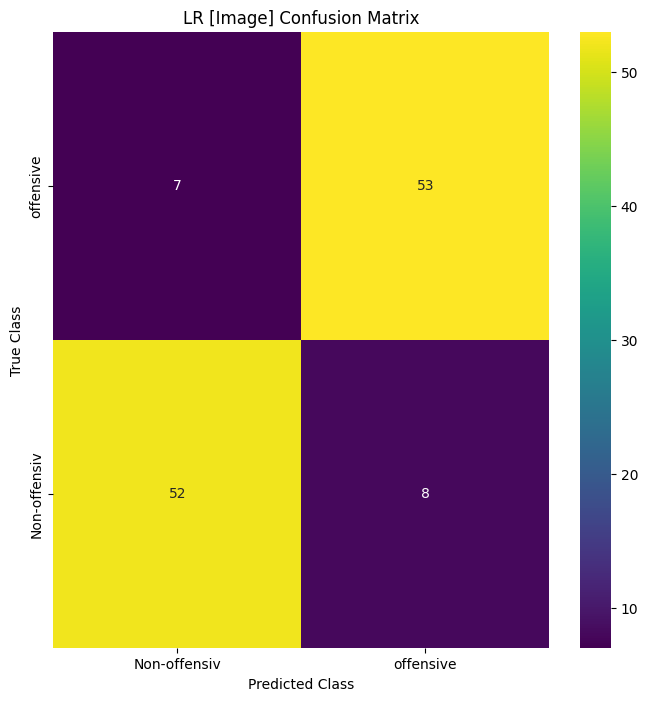

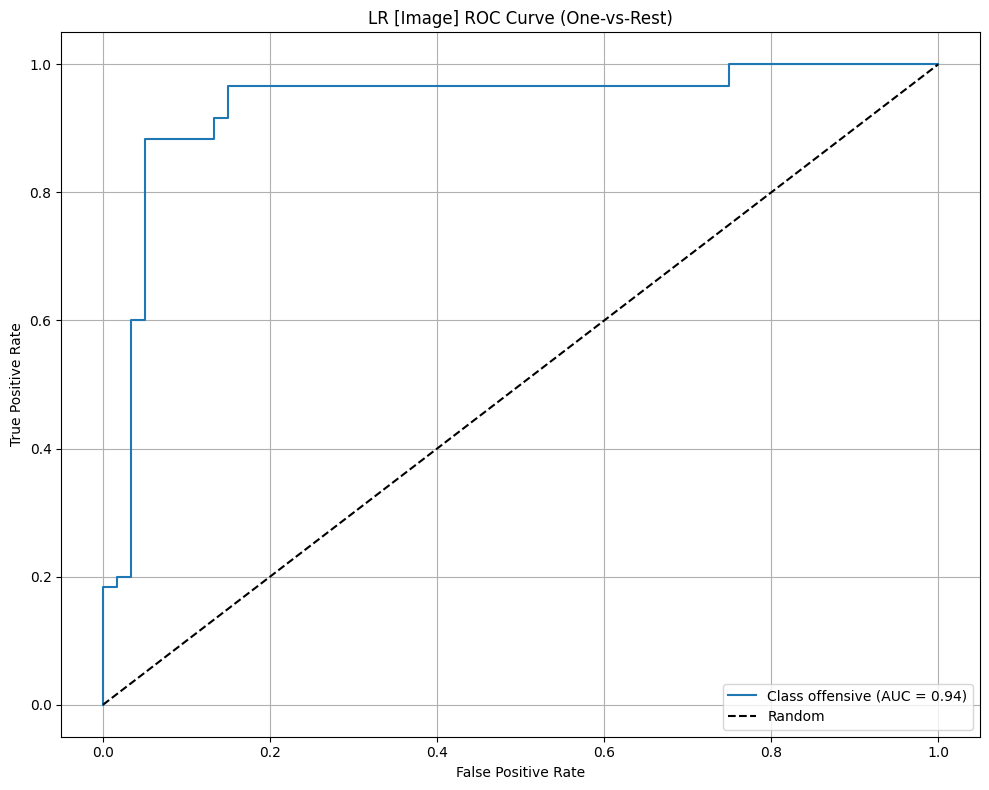

LR [label] Accuracy  : 90.50
LR [label] Precision : 90.54
LR [label] Recall    : 90.50
LR [label] FScore    : 90.50
LR [label] Classification Report
LR [label]
              precision    recall  f1-score   support

Non-offensiv       0.92      0.89      0.90       100
   offensive       0.89      0.92      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200




C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


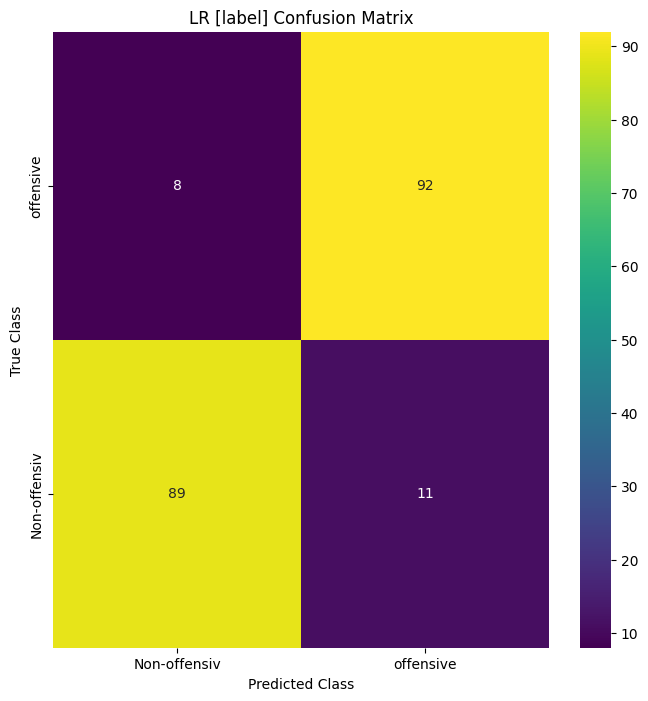

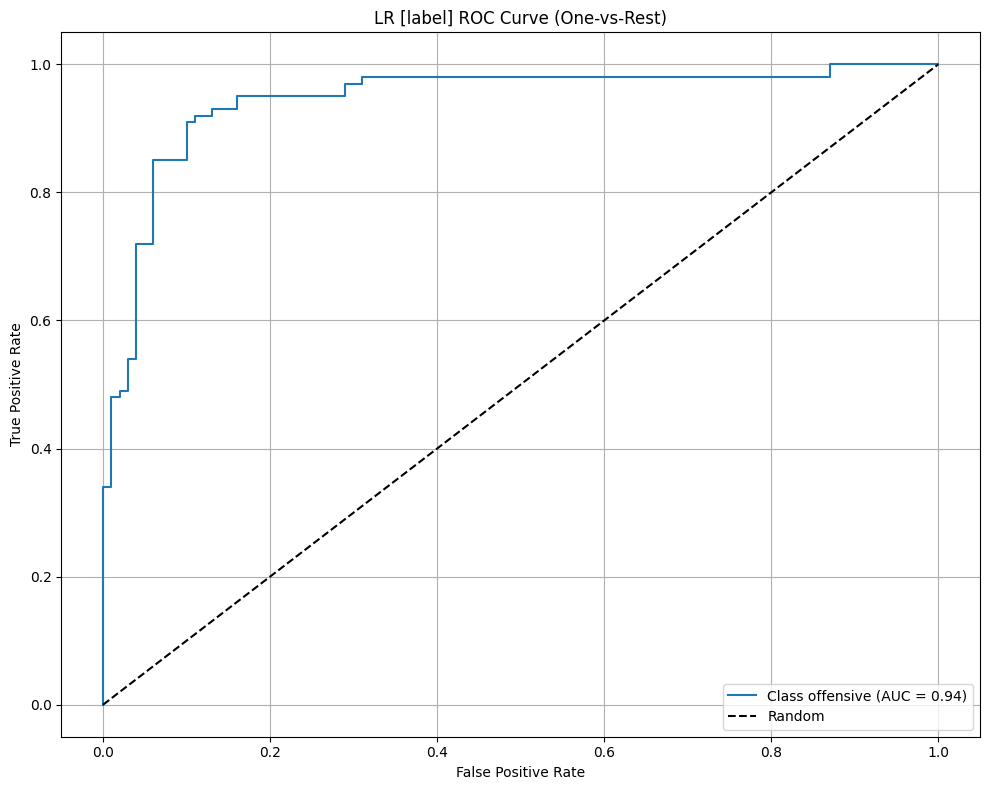

({'LR_image': LogisticRegression(max_iter=10)},
 {'label_LR': LogisticRegression(max_iter=10)})

In [18]:
train_logistic_regression(splits, metrics_calculator, Algorithm_prefix="LR")

In [19]:
# ---------------- Decision Tree Classifier ----------------
def train_decision_tree(splits, metrics_calculator, Algorithm_prefix="DTC"):
    image_model = {}
    tabular_model = {}

    if 'image' in splits:
        X_train, X_test = splits['image']['X_train'], splits['image']['X_test']
        y_train, y_test = splits['image']['y_train'], splits['image']['y_test']

        mdl = DecisionTreeClassifier(max_depth=5, random_state=42)
        mdl.fit(X_train, y_train)

        y_pred = mdl.predict(X_test)
        try: y_score = mdl.predict_proba(X_test)
        except AttributeError: y_score = None

        algo_name = f"{Algorithm_prefix} [Image]"
        metrics_calculator.calculate_metrics(algo_name, y_pred, y_test, y_score)
        image_model[f"{Algorithm_prefix}_image"] = mdl

    if 'tabular' in splits:
        for target_name, data in splits['tabular'].items():
            X_train, X_test = data['X_train'], data['X_test']
            y_train, y_test = data['y_train'], data['y_test']

            mdl = DecisionTreeClassifier(max_depth=5, random_state=42)
            mdl.fit(X_train, y_train)

            y_pred = mdl.predict(X_test)
            try: y_score = mdl.predict_proba(X_test)
            except AttributeError: y_score = None

            algo_name = f"{Algorithm_prefix} [{target_name}]"
            metrics_calculator.calculate_metrics(algo_name, y_pred, y_test, y_score)
            tabular_model[f"{target_name}_{Algorithm_prefix}"] = mdl

    return image_model, tabular_model


DTC [Image] Accuracy  : 77.50
DTC [Image] Precision : 79.33
DTC [Image] Recall    : 77.50
DTC [Image] FScore    : 77.14
DTC [Image] Classification Report
DTC [Image]
              precision    recall  f1-score   support

Non-offensiv       0.87      0.65      0.74        60
   offensive       0.72      0.90      0.80        60

    accuracy                           0.78       120
   macro avg       0.79      0.78      0.77       120
weighted avg       0.79      0.78      0.77       120




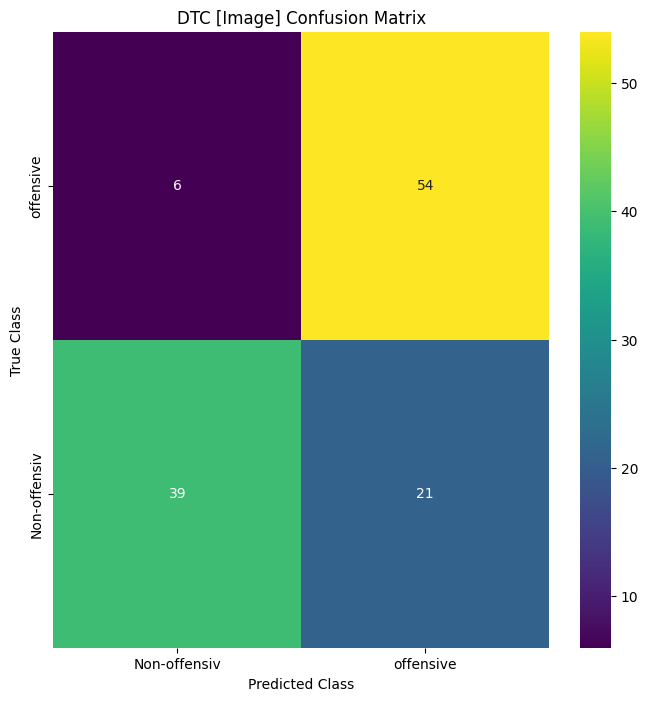

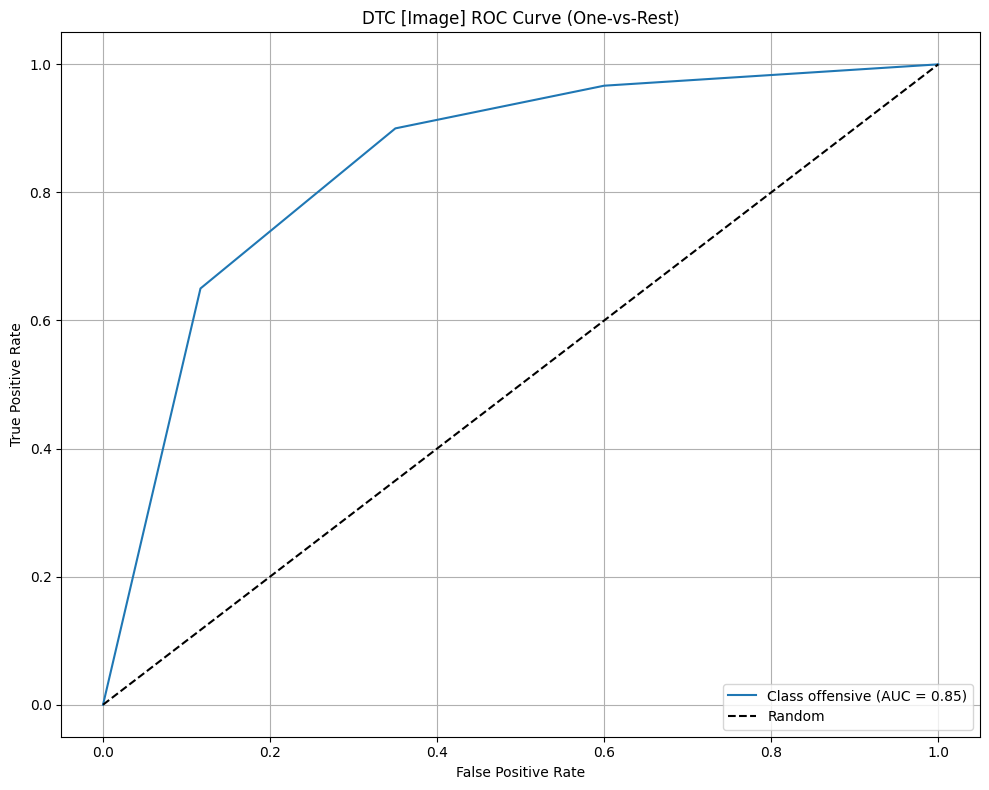

DTC [label] Accuracy  : 87.50
DTC [label] Precision : 87.53
DTC [label] Recall    : 87.50
DTC [label] FScore    : 87.50
DTC [label] Classification Report
DTC [label]
              precision    recall  f1-score   support

Non-offensiv       0.86      0.89      0.88       100
   offensive       0.89      0.86      0.87       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200




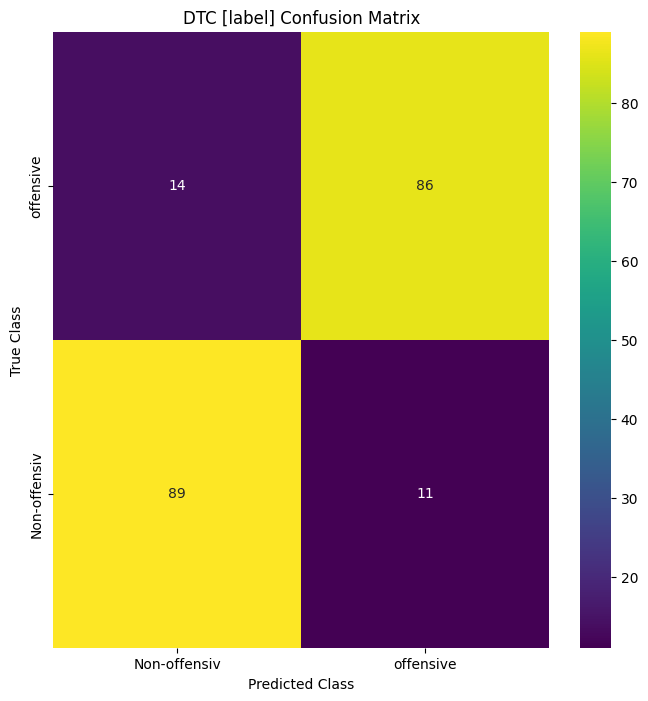

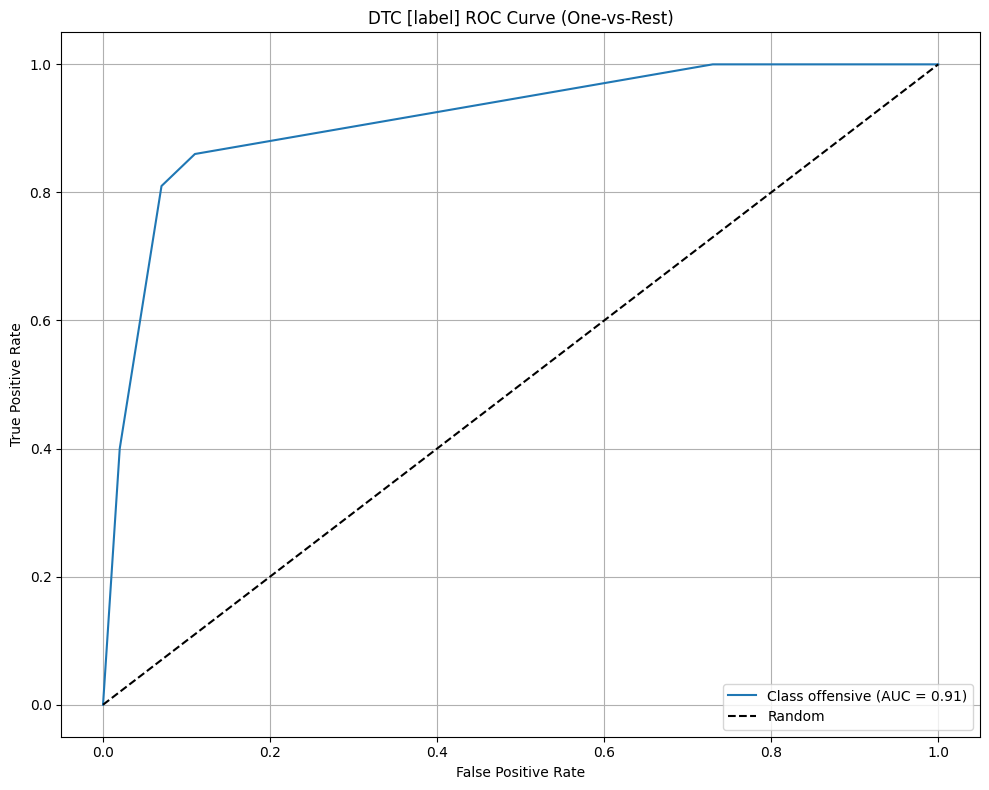

({'DTC_image': DecisionTreeClassifier(max_depth=5, random_state=42)},
 {'label_DTC': DecisionTreeClassifier(max_depth=5, random_state=42)})

In [20]:
train_decision_tree(splits, metrics_calculator, Algorithm_prefix="DTC")

In [21]:
# ---------------- K-Nearest Neighbors ----------------
def train_knn(splits, metrics_calculator, Algorithm_prefix="KNN"):
    image_model = {}
    tabular_model = {}

    if 'image' in splits:
        X_train, X_test = splits['image']['X_train'], splits['image']['X_test']
        y_train, y_test = splits['image']['y_train'], splits['image']['y_test']

        mdl = KNeighborsClassifier(n_neighbors=5)
        mdl.fit(X_train, y_train)

        y_pred = mdl.predict(X_test)
        try: y_score = mdl.predict_proba(X_test)
        except AttributeError: y_score = None

        algo_name = f"{Algorithm_prefix} [Image]"
        metrics_calculator.calculate_metrics(algo_name, y_pred, y_test, y_score)
        image_model[f"{Algorithm_prefix}_image"] = mdl

    if 'tabular' in splits:
        for target_name, data in splits['tabular'].items():
            X_train, X_test = data['X_train'], data['X_test']
            y_train, y_test = data['y_train'], data['y_test']

            mdl = KNeighborsClassifier(n_neighbors=5)
            mdl.fit(X_train, y_train)

            y_pred = mdl.predict(X_test)
            try: y_score = mdl.predict_proba(X_test)
            except AttributeError: y_score = None

            algo_name = f"{Algorithm_prefix} [{target_name}]"
            metrics_calculator.calculate_metrics(algo_name, y_pred, y_test, y_score)
            tabular_model[f"{target_name}_{Algorithm_prefix}"] = mdl

    return image_model, tabular_model


KNN [Image] Accuracy  : 80.00
KNN [Image] Precision : 80.86
KNN [Image] Recall    : 80.00
KNN [Image] FScore    : 79.86
KNN [Image] Classification Report
KNN [Image]
              precision    recall  f1-score   support

Non-offensiv       0.86      0.72      0.78        60
   offensive       0.76      0.88      0.82        60

    accuracy                           0.80       120
   macro avg       0.81      0.80      0.80       120
weighted avg       0.81      0.80      0.80       120




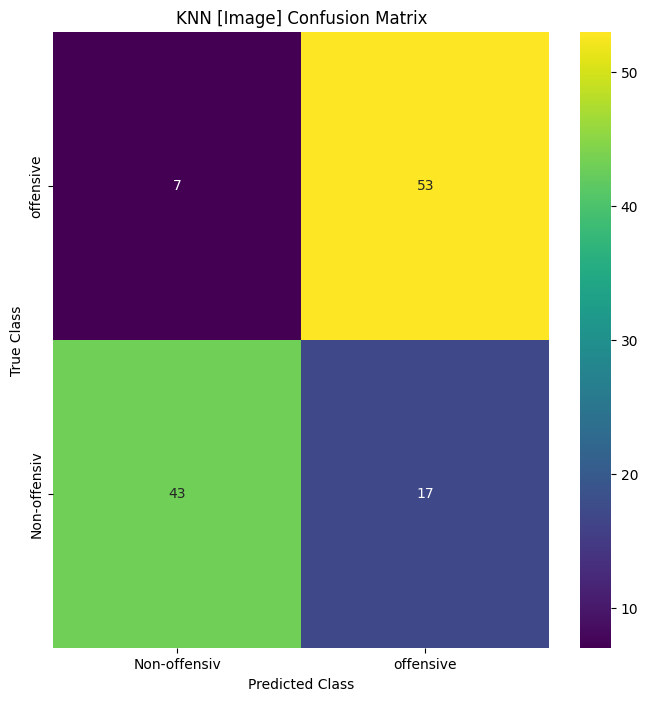

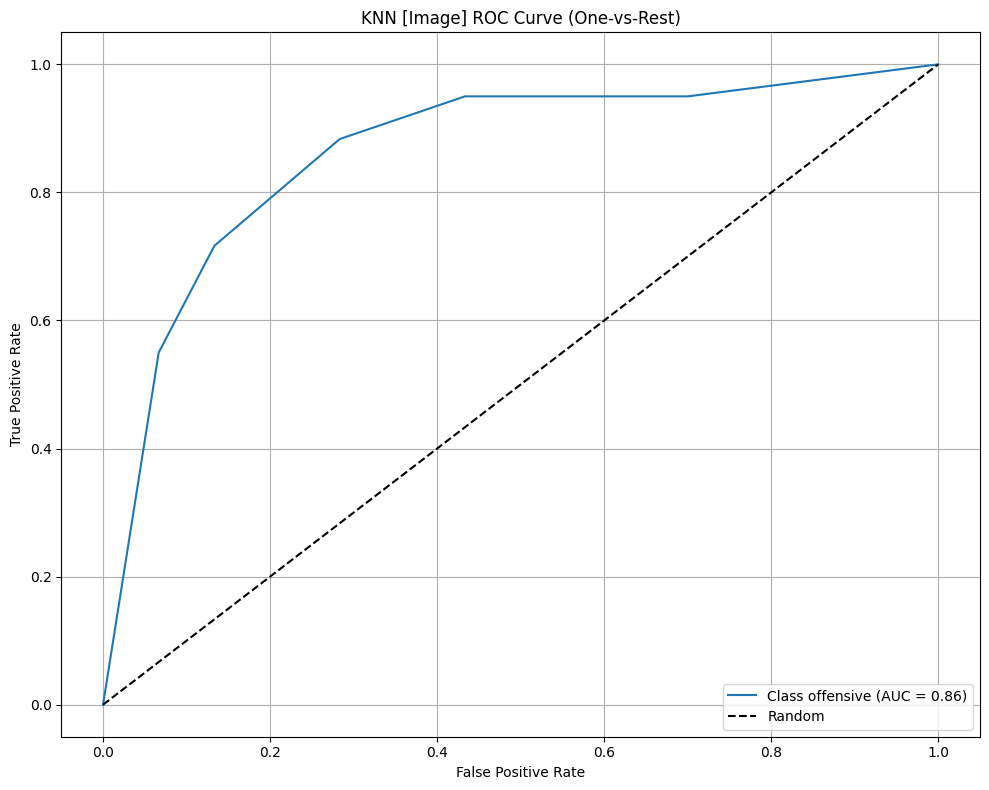

KNN [label] Accuracy  : 86.00
KNN [label] Precision : 86.01
KNN [label] Recall    : 86.00
KNN [label] FScore    : 86.00
KNN [label] Classification Report
KNN [label]
              precision    recall  f1-score   support

Non-offensiv       0.87      0.85      0.86       100
   offensive       0.85      0.87      0.86       100

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200




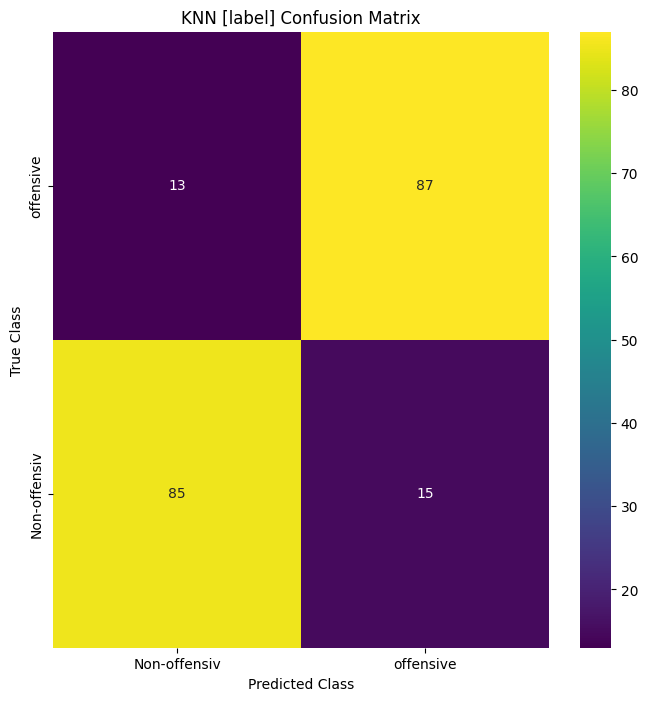

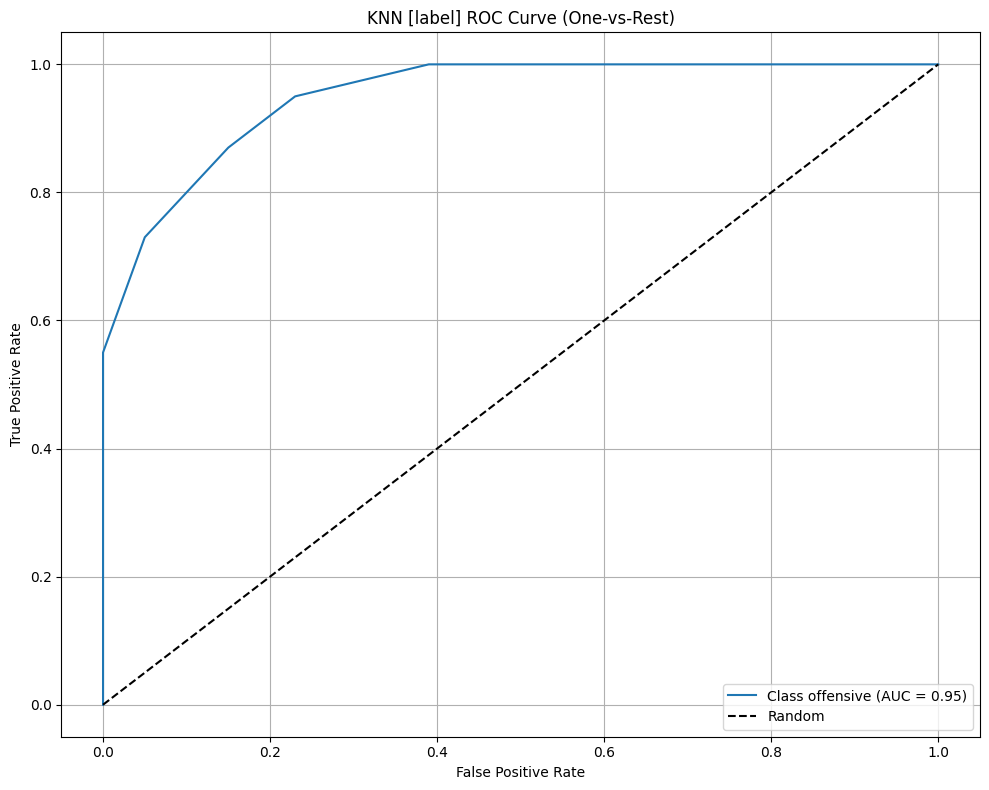

({'KNN_image': KNeighborsClassifier()}, {'label_KNN': KNeighborsClassifier()})

In [22]:
from sklearn.neighbors import KNeighborsClassifier

train_knn(splits, metrics_calculator, Algorithm_prefix="KNN")

In [23]:
import os
import joblib

def train_slim(splits, metrics_calculator, Algorithm_prefix="SLIM", model_dir="model"):

    os.makedirs(model_dir, exist_ok=True)
    image_model = {}
    tabular_model = {}

    # ----------- Image dataset -----------
    if 'image' in splits:
        X_train, X_test = splits['image']['X_train'], splits['image']['X_test']
        y_train, y_test = splits['image']['y_train'], splits['image']['y_test']

        model_path = os.path.join(model_dir, f"{Algorithm_prefix}_image.pkl")
        if os.path.exists(model_path):
            mdl = joblib.load(model_path)
            print(f"✅ Loaded existing image model: {model_path}")
        else:
            mdl = SLIMClassifier()
            mdl.fit(X_train, y_train)
            joblib.dump(mdl, model_path)
            print(f"✅ Trained and saved image model: {model_path}")

        y_pred = mdl.predict(X_test)
        try: y_score = mdl.predict_proba(X_test)
        except AttributeError: y_score = None

        algo_name = f"{Algorithm_prefix} [Image]"
        metrics_calculator.calculate_metrics(algo_name, y_pred, y_test, y_score)
        image_model[f"{Algorithm_prefix}_image"] = mdl

    # ----------- Tabular dataset -----------
    if 'tabular' in splits:
        for target_name, data in splits['tabular'].items():
            X_train, X_test = data['X_train'], data['X_test']
            y_train, y_test = data['y_train'], data['y_test']

            model_path = os.path.join(model_dir, f"{target_name}_{Algorithm_prefix}.pkl")
            if os.path.exists(model_path):
                mdl = joblib.load(model_path)
                print(f"✅ Loaded existing tabular model: {model_path}")
            else:
                mdl = SLIMClassifier()
                mdl.fit(X_train, y_train)
                joblib.dump(mdl, model_path)
                print(f"✅ Trained and saved tabular model: {model_path}")

            y_pred = mdl.predict(X_test)
            try: y_score = mdl.predict_proba(X_test)
            except AttributeError: y_score = None

            algo_name = f"{Algorithm_prefix} [{target_name}]"
            metrics_calculator.calculate_metrics(algo_name, y_pred, y_test, y_score)
            tabular_model[f"{target_name}_{Algorithm_prefix}"] = mdl

    return image_model, tabular_model


✅ Loaded existing image model: model\SLIM_image.pkl
SLIM [Image] Accuracy  : 100.00
SLIM [Image] Precision : 100.00
SLIM [Image] Recall    : 100.00
SLIM [Image] FScore    : 100.00
SLIM [Image] Classification Report
SLIM [Image]
              precision    recall  f1-score   support

Non-offensiv       1.00      1.00      1.00        60
   offensive       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120




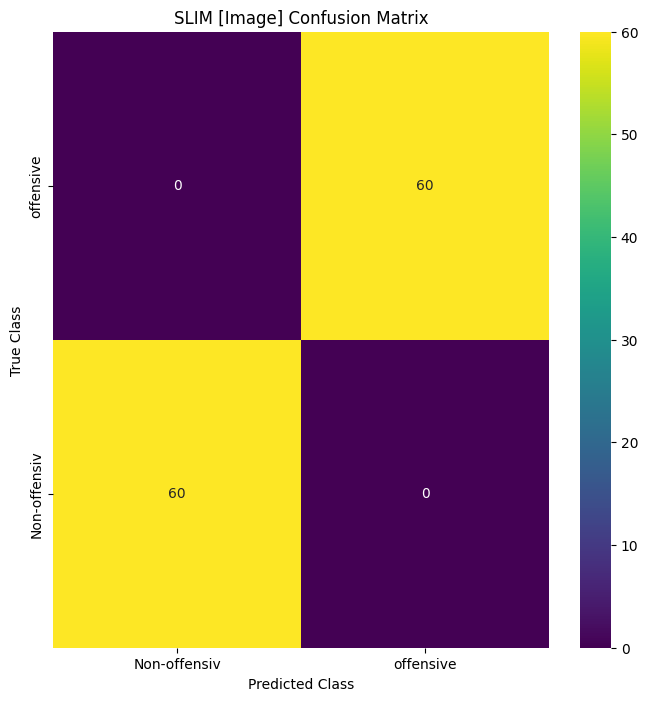

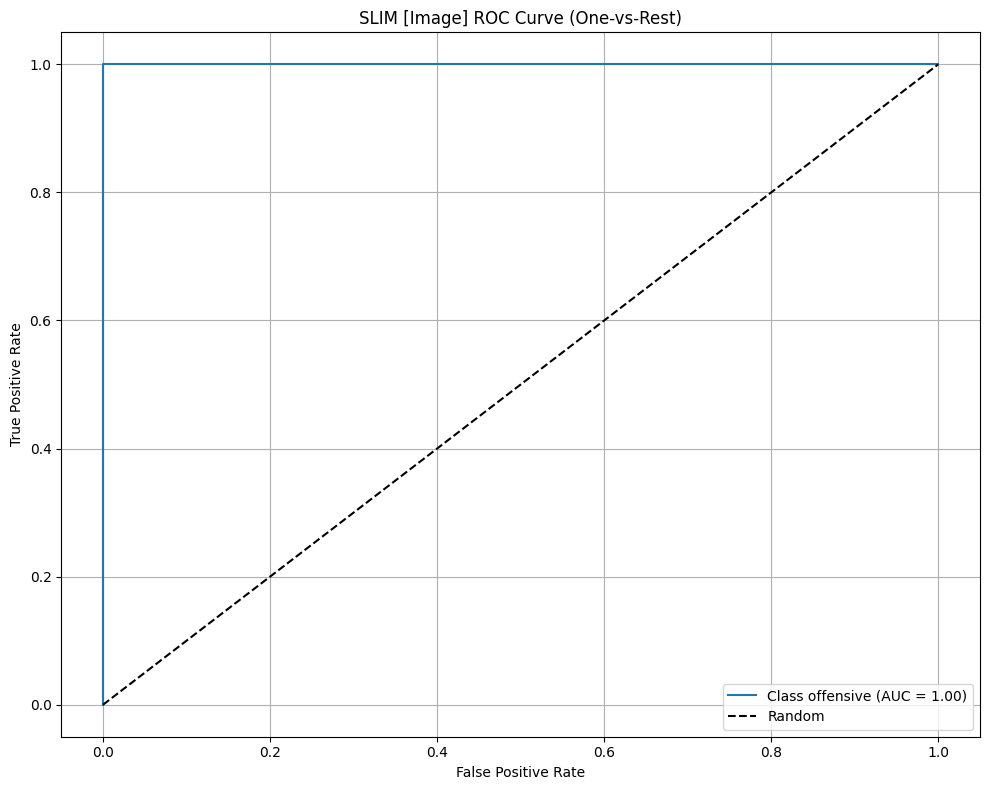

✅ Loaded existing tabular model: model\label_SLIM.pkl
SLIM [label] Accuracy  : 98.00
SLIM [label] Precision : 98.00
SLIM [label] Recall    : 98.00
SLIM [label] FScore    : 98.00
SLIM [label] Classification Report
SLIM [label]
              precision    recall  f1-score   support

Non-offensiv       0.98      0.98      0.98       100
   offensive       0.98      0.98      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200




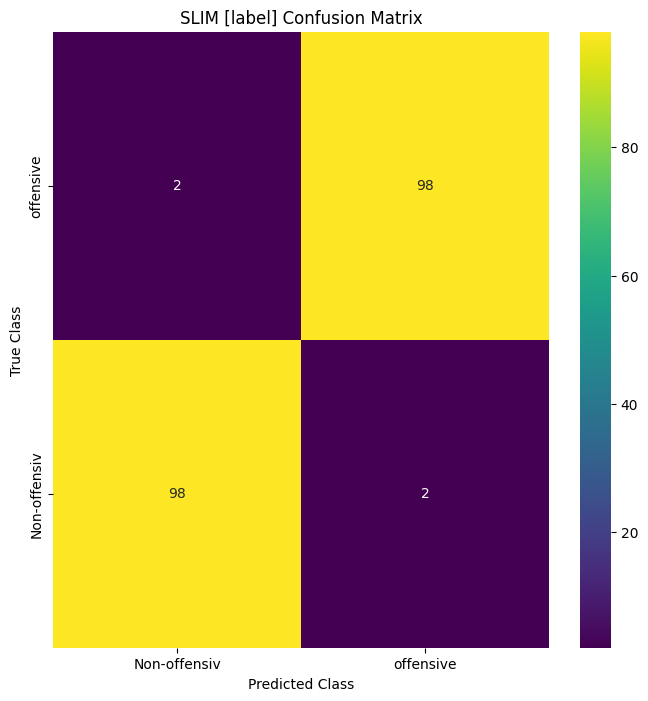

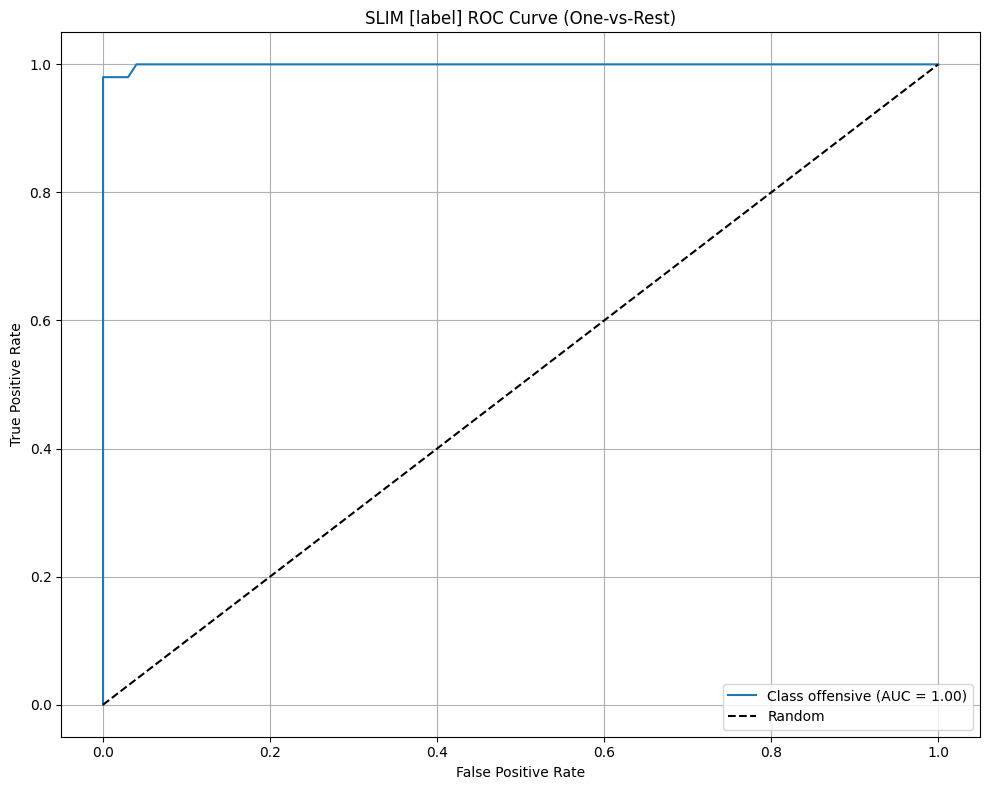

In [24]:
image_model, tabular_model = train_slim(splits, metrics_calculator, Algorithm_prefix="SLIM")

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

def predict_from_image(file_path):

    # -------- Preprocess Image --------
    pixel_values = preprocess_image(file_path)  # tensor on device
    features = extract_features_image(pixel_values)  # NumPy array for SLIMClassifier

    # Convert features to 2D array if needed
    if isinstance(features, torch.Tensor):
        features = features.detach().cpu().numpy()
    if len(features.shape) == 1:
        features = features.reshape(1, -1)

    # -------- Prediction --------
    model_key = list(image_model.keys())[0]
    mdl = image_model[model_key]
    y_pred = mdl.predict(features)[0]
    pred_class = labels1[y_pred]
    # -------- Display Image with Prediction as Title --------
    img = Image.open(file_path).convert("RGB")
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction Output: {pred_class}", fontsize=20, color='red')
    plt.show()

    return pred_class


C:\Users\dell\Desktop\nlp\6. Hate Speech in Memes\MemeSentinel\Test Images\0bOKK62.png


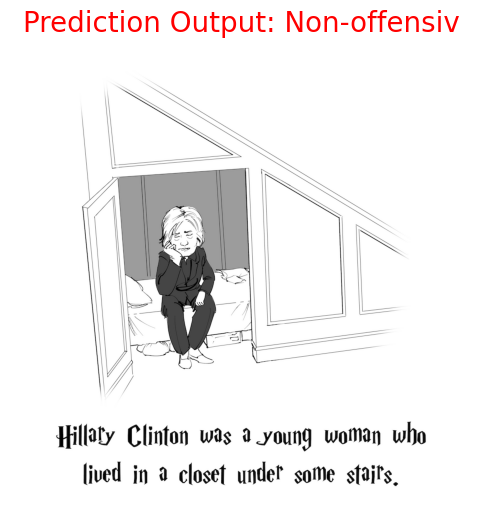

'Non-offensiv'

In [26]:
file_path = r"C:\Users\dell\Desktop\nlp\6. Hate Speech in Memes\MemeSentinel\Test Images\0bOKK62.png"
predict_from_image(file_path)

C:\Users\dell\Desktop\nlp\6. Hate Speech in Memes\MemeSentinel\Test Images\0EwB4LT.png


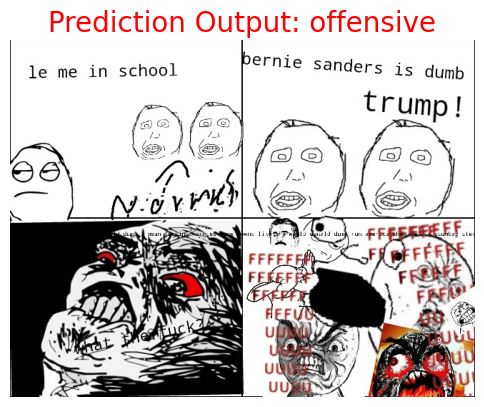

'offensive'

In [27]:
file_path = r"C:\Users\dell\Desktop\nlp\6. Hate Speech in Memes\MemeSentinel\Test Images\0EwB4LT.png"
predict_from_image(file_path)

In [ ]:
test_path=r"MultiOFF_Dataset\Split Dataset\Validation_meme_dataset.csv"

In [ ]:
df_test1 = pd.read_csv(test_path)
df_result = df_test1.copy()
df_test1

,sentence
0,WE LIKE IKE I LIKE IKE FRANK CULOTTA REPUBLICA...
1,Glory to Bern .
2,My mom got kicked out of her emotionally abusi...
3,J. TRUMP DONALD MA DE N MEXIC i RN 47333
4,score hidden ] 5 hours ago My friend committed...
...,...
144,Pussy almost brings down Trump Weiner knocks o...
145,CLINTON SAID SHE B BRINGING BACK RUGRATIS AM G...
146,2 hrs THAT AwKWARD MoMENT wHEN ... I. BERNIE S...
147,FOR HILLARY BLOOD ON YOUR HANDS Stop Voting ou...


In [ ]:
df_test,_ = preprocess_data(df_test1)

Preprocessing data (no saving)


In [ ]:
features_test = feature_extraction(df_test,method='XLNet_word_embeddings',is_train=None)

[INFO] Feature extraction method: XLNet_word_embeddings, Train mode: None
[INFO] Performing XLNet feature extraction for testing...


Extracting XLNet embeddings: 100%|███████████████████████████████████████████████████████| 5/5 [00:13<00:00,  2.77s/it]


In [ ]:
model_path = r"Model\label_SLIM.pkl"
model = joblib.load(model_path)
y_pred = model.predict(features_test)
mapped_labels = [labels1[i] for i in y_pred]
df_result[f'Predicted_output'] = mapped_labels

In [33]:
df_result

,sentence,Predicted_output
0,WE LIKE IKE I LIKE IKE FRANK CULOTTA REPUBLICA...,offensive
1,Glory to Bern .,offensive
2,My mom got kicked out of her emotionally abusi...,Non-offensiv
3,J. TRUMP DONALD MA DE N MEXIC i RN 47333,Non-offensiv
4,score hidden ] 5 hours ago My friend committed...,Non-offensiv
...,...,...
144,Pussy almost brings down Trump Weiner knocks o...,Non-offensiv
145,CLINTON SAID SHE B BRINGING BACK RUGRATIS AM G...,offensive
146,2 hrs THAT AwKWARD MoMENT wHEN ... I. BERNIE S...,Non-offensiv
147,FOR HILLARY BLOOD ON YOUR HANDS Stop Voting ou...,offensive


In [34]:
results_df = metrics_calculator.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
results_df = results_df.round(3)
results_df

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,LR [Image],87.5,87.510,87.5,87.499
1,LR [label],90.5,90.536,90.5,90.498
2,DTC [Image],77.5,79.333,77.5,77.143
3,DTC [label],87.5,87.534,87.5,87.497
4,KNN [Image],80.0,80.857,80.0,79.860
5,KNN [label],86.0,86.014,86.0,85.999
6,SLIM [Image],100.0,100.000,100.0,100.000
7,SLIM [label],98.0,98.000,98.0,98.000
